# Temas Tratados en el Trabajo Práctico 3

* Estrategias de búsqueda local.

* Algoritmos Evolutivos.

* Problemas de Satisfacción de Restricciones.

# Ejercicios Teóricos

1. ¿Qué mecanismo de detención presenta el algoritmo de Ascensión de Colinas? Describa el problema que puede presentar este mecanismo y cómo se llaman las áreas donde ocurren estos problemas.


2. Describa las distintas heurísticas que se emplean en un problema de Satisfacción de Restricciones.

3. Se desea colorear el rompecabezas mostrado en la imagen con 7 colores distintos de manera que ninguna pieza tenga el mismo color que sus vecinas. Realice en una tabla el proceso de una búsqueda con Comprobación hacia Adelante empleando una heurística del Valor más Restringido.

In [ ]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URL directa de Google Drive
#url = "https://drive.google.com/uc?export=view&id=1j94jFVxVG9y_ZnrMWOscQGb2MZ0Cdb3R"
url = "https://drive.google.com/uc?export=view&id=1LwSM11NOxZL_0JQwFLEql8YGn7H642dU"

# Descargar la imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Ocultar ejes
plt.show()

#Nota: la imagen fue cambiada para representar los nodos

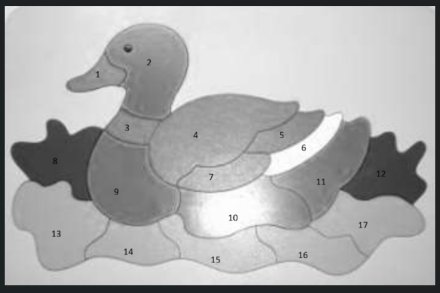

Se planteó la siguiente distribución de nodos, llegando a la distribución:

|Nodo |Restricciones |Vecinos|
|-|-|-|
|1|1|2|
|2|3|1, 3, 4|
|3|3|2, 4, 9|
|4|5|2, 3, 5, 7, 9|
|5|	3|	4, 6, 7|
|6|	4|	5, 7, 10, 11|
|7|	4|	4, 5, 6, 10|
|8|	2|	9, 13|
|9|	7|	3, 4, 8, 10, 13, 14,15|
|10|	7|	6, 7, 9, 11, 15, 16,17|
|11|	4|	6, 10, 12, 17|
|12|	2|	11, 17|
|13|	3|	8, 9, 14|
|14|	3|	9, 13, 15|
|15|	4|	9,10, 14, 16|
|16|	3|	10, 15, 17|
|17|	4|	10,11, 12, 16|

Se debe notar que se consideró que el primer nodo a ser afectado será el nodo con mayor cantidad de vecinos

|Nodo|Restricciones|Vecinos|
|-|-|-|
|9|	7|	3, 4, 8, 10, 13, 14,15|

Luego, dentro de los nodos con menores dominios, se seleccionan también los nodos que mas vecinos tengan (en el caso del segundo nodo, fue el nodo 10.), y el ultimo criterio es el orden numérico.

Siguiendo estos criterios, se obtuvo el siguiente orden: 

|Paso  | Nodo  | Color  | Efecto |
|------|-------|--------|-----------------------------------------|
|1     | 9     | 1      | Eliminado color 1 de: [3, 4, 8, 10, 13, 14, 15]|
|2     | 10    | 2      | Eliminado color 2 de: [6, 7, 11, 15, 16, 17]|
|3     | 15    | 3      | Eliminado color 3 de: [14, 16]|
|4     | 14    | 2      | Eliminado color 2 de: [13]|
|5     | 13    | 3      | Eliminado color 3 de: [8]|
|6     | 16    | 1      | Eliminado color 1 de: [17]|
|7     | 17    | 3      | Eliminado color 3 de: [11, 12]|
|8     | 11    | 1      | Eliminado color 1 de: [6, 12]|
|9     | 6     | 3      | Eliminado color 3 de: [5, 7]|
|10    | 7     | 1      | Eliminado color 1 de: [5]|
|11    | 5     | 2      | Eliminado color 2 de: [4]|
|12    | 4     | 3      | Eliminado color 3 de: [2, 3]|
|13    | 3     | 2      | Eliminado color 2 de: [2]|
|14    | 2     | 1      | Eliminado color 1 de: [1]|
|15    | 8     | 2      | Eliminado color 2 de: [Ninguno]|
|16    | 12    | 2      | Eliminado color 2 de: [Ninguno]|
|17    | 1     | 2      | Eliminado color 2 de: [Ninguno]|

visualizado en la tabla de los dominios, con el criterio de que dentro del dominio se elija el color de menor numero, se llega a la siguiente tabla de dominios:

|Nodo seleccionado|1|2|3|4|5|6|7|8|9|10|11|12|13|14|15|16|17|
|-|-|-|-|-|-|-|-|-|-|-|-|-|-|-|-|-|-|
|0|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|
|9|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|1|2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|
|10|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|1-2-3-4-5-6-7|1-3-4-5-6-7|1-3-4-5-6-7|2-3-4-5-6-7|1|2|1-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|3-4-5-6-7|1-3-4-5-6-7|1-3-4-5-6-7|
|15|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|1-2-3-4-5-6-7|1-3-4-5-6-7|1-3-4-5-6-7|2-3-4-5-6-7|1|2|1-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-4-5-6-7|3|1-4-5-6-7|1-3-4-5-6-7|
|14|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|1-2-3-4-5-6-7|1-3-4-5-6-7|1-3-4-5-6-7|2-3-4-5-6-7|1|2|1-3-4-5-6-7|1-2-3-4-5-6-7|3-4-5-6-7|2|3|1-4-5-6-7|1-3-4-5-6-7|
|13|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|1-2-3-4-5-6-7|1-3-4-5-6-7|1-3-4-5-6-7|2-4-5-6-7|1|2|1-3-4-5-6-7|1-2-3-4-5-6-7|3|2|3|1-4-5-6-7|1-3-4-5-6-7|
|16|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|1-2-3-4-5-6-7|1-3-4-5-6-7|1-3-4-5-6-7|2-4-5-6-7|1|2|1-3-4-5-6-7|1-2-3-4-5-6-7|3|2|3|1|3-4-5-6-7|
|17|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|1-2-3-4-5-6-7|1-3-4-5-6-7|1-3-4-5-6-7|2-4-5-6-7|1|2|1-4-5-6-7|1-2-4-5-6-7|3|2|3|1|3|
|11|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|1-2-3-4-5-6-7|3-4-5-6-7|1-3-4-5-6-7|2-4-5-6-7|1|2|1|2-4-5-6-7|3|2|3|1|3|
|6|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|1-2-4-5-6-7|3|1-4-5-6-7|2-4-5-6-7|1|2|1|2-4-5-6-7|3|2|3|1|3|
|7|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|2-3-4-5-6-7|2-4-5-6-7|3|1|2-4-5-6-7|1|2|1|2-4-5-6-7|3|2|3|1|3|
|5|1-2-3-4-5-6-7|1-2-3-4-5-6-7|2-3-4-5-6-7|3-4-5-6-7|2|3|1|2-4-5-6-7|1|2|1|2-4-5-6-7|3|2|3|1|3|
|4|1-2-3-4-5-6-7|1-2-4-5-6-7|2-4-5-6-7|3|2|3|1|2-4-5-6-7|1|2|1|2-4-5-6-7|3|2|3|1|3|
|3|1-2-3-4-5-6-7|1-4-5-6-7|2|3|2|3|1|2-4-5-6-7|1|2|1|2-4-5-6-7|3|2|3|1|3|
|2|2-3-4-5-6-7|1|2|3|2|3|1|2-4-5-6-7|1|2|1|2-4-5-6-7|3|2|3|1|3|
|8|2-3-4-5-6-7|1|2|3|2|3|1|2|1|2|1|2-4-5-6-7|3|2|3|1|3|
|12|2-3-4-5-6-7|1|2|3|2|3|1|2|1|2|1|2|3|2|3|1|3|
|1|2|1|2|3|2|3|1|2|1|2|1|2|3|2|3|1|3|


# Ejercicios de Implementación

4. Encuentre el máximo de la función $f(x) = \frac{\sin(x)}{x + 0.1}$ en $x \in [-10; -6]$ con un error menor a $0.1$ utilizando el algoritmo _hill climbing_.

5. Diseñe e implemente un algoritmo de Recocido Simulado para que juegue contra usted al Ta-te-ti. Varíe los valores de temperatura inicial entre partidas, ¿qué diferencia observa cuando la temperatura es más alta con respecto a cuando la temperatura es más baja?


6. Diseñe e implemente un algoritmo genético para cargar una grúa con $n=10\;cajas$ que puede soportar un peso máximo $C=1000\;kg$. Cada caja *j* tiene asociado un precio $p_j$ y un peso $w_j$ como se indica en la tabla de abajo, de manera que el algoritmo debe ser capaz de maximizar el precio sin superar el límite de carga.

<table><tr><td>Elemento ($j$)</td><td>1</td><td>2</td><td>3</td><td>4</td><td>5</td><td>6</td><td>7</td><td>8</td><td>9</td><td>10</td></tr>

<tr><td>Precio ($p_j$)</td><td>100</td><td>50</td><td>115</td><td>25</td><td>200</td><td>30</td><td>40</td><td>100</td><td>100</td><td>100</td></tr>

<tr><td>Peso ($w_j$)</td><td>300</td><td>200</td><td>450</td><td>145</td><td>664</td><td>90</td><td>150</td><td>355</td><td>401</td><td>395</td></tr></table><br>

        6.1 En primer lugar, es necesario representar qué cajas estarán cargadas en la grúa y cuáles no. Esta representación corresponde a un Individuo con el que trabajará el algoritmo.

        6.2 A continuación, genere una Población que contenga un número $N$ de individuos (se recomienda elegir un número par). Es necesario crear un control que verifique que ninguno de los individuos supere el peso límite.

        6.3 Cree ahora una función que permita evaluar la Idoneidad de cada individuo y seleccione $N/2$ parejas usando el método de la ruleta.

        6.4 Por último, Cruce las parejas elegidas, aplique un mecanismo de Mutación y verifique que los individuos de la nueva población no superen el límite de peso.

        6.5 Realice este proceso iterativamente hasta que se cumpla el mecanismo de detención de su elección y muestre el mejor individuo obtenido junto con el peso y el precio que alcanza.

# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2023) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)